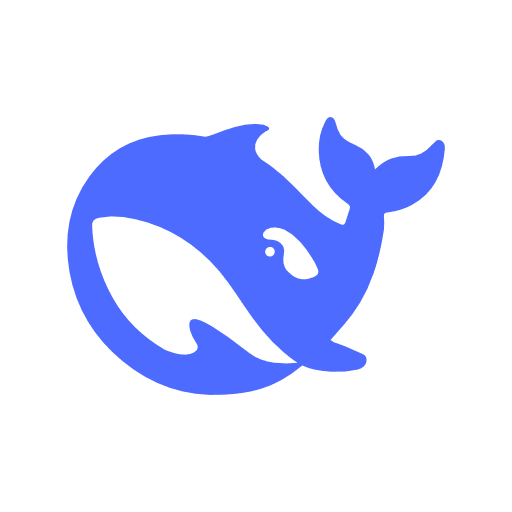

# Chapter 6 — Knowledge Agents with Local LLMs (Ollama)

**Book:** *30 Agents Every AI Engineer Must Build* by Imran Ahmad (Packt, 2026)  
**Author:** Imran Ahmad  
**Variant:** Local LLM Mode — runs entirely on your machine using Ollama

---

This notebook is a **localized variant** of `chapter_06_knowledge_agents.ipynb`.  
Instead of OpenAI/Anthropic/Google APIs, it uses **Ollama** to run open-source LLMs locally:

| Component | Cloud Version | Local Version |
|---|---|---|
| **LLM** | GPT-4o / Claude / Gemini | DeepSeek V2 16B (via Ollama) |
| **Embeddings** | OpenAI text-embedding-3-large | Llama 3.1 8B (via Ollama) |
| **Vector Store** | FAISS | FAISS (unchanged) |
| **API Keys** | Required | **None** |
| **Internet** | Required | **Not required** |

### Prerequisites

```bash
# Ollama must be installed and running
ollama list  # Should show deepseek-v2:16b and llama3.1:8b

# Install langchain-ollama in the chapter 6 environment
pip install langchain-ollama
```

### Agents Covered

1. **Knowledge Retrieval Agent** (RAG with local embeddings + local LLM)  
2. **Document Intelligence Agent** (OCR + local LLM extraction)  
3. **Scientific Research Agent** (clustering + local LLM synthesis)

## 0. Setup & Configuration

In [1]:
# ── 0.1 Dependency Check ─────────────────────────────────────────
import importlib

REQUIRED = [
    "langchain_ollama", "langchain_text_splitters",
    "langchain_community", "numpy", "pandas",
    "sklearn", "sentence_transformers",
]

missing = []
for pkg in REQUIRED:
    try:
        importlib.import_module(pkg)
    except ImportError:
        missing.append(pkg)

if missing:
    print(f"Missing packages: {missing}")
    print("Run: pip install langchain-ollama langchain-community langchain-text-splitters")
    print("     pip install numpy pandas scikit-learn sentence-transformers")
else:
    print("All dependencies satisfied.")

All dependencies satisfied.


In [2]:
# ── 0.2 Import Shared Utilities ──────────────────────────────────
import os
import sys

from agent_utils import (
    ColorLogger, fail_gracefully, log,
    MockEmbeddings, MockLLM, MockRetrievalQAResult,
    mock_search_arxiv, mock_pytesseract_output,
    MOCK_EXTRACTED_FIELDS,
)

In [3]:
# ── 0.3 Verify Ollama is Running ─────────────────────────────────
import subprocess

OLLAMA_LLM_MODEL = "deepseek-v2:16b"         # Main LLM for generation
OLLAMA_EMBED_MODEL = "llama3.1:8b"            # Embeddings model

def check_ollama():
    """Verify Ollama is running and required models are available."""
    try:
        result = subprocess.run(
            ["ollama", "list"],
            capture_output=True, text=True, timeout=10
        )
        if result.returncode != 0:
            return False, "Ollama is not running. Start it with: sudo systemctl start ollama"

        output = result.stdout.lower()
        missing_models = []
        for model in [OLLAMA_LLM_MODEL, OLLAMA_EMBED_MODEL]:
            # Check model name (before the colon tag or full name)
            if model.lower().replace(":", " ").split()[0] not in output:
                missing_models.append(model)

        if missing_models:
            return False, f"Missing models: {missing_models}. Pull with: ollama pull <model>"

        return True, result.stdout.strip()
    except FileNotFoundError:
        return False, "Ollama not installed. Install: curl -fsSL https://ollama.com/install.sh | sh"
    except Exception as e:
        return False, f"Ollama check failed: {e}"

ollama_ok, ollama_msg = check_ollama()

if ollama_ok:
    LOCAL_MODE = True
    print("=" * 65)
    print("  LOCAL LLM MODE ACTIVE")
    print(f"  LLM:        {OLLAMA_LLM_MODEL} (via Ollama)")
    print(f"  Embeddings: {OLLAMA_EMBED_MODEL} (via Ollama)")
    print("  No API keys required. All processing stays on your machine.")
    print("=" * 65)
    print(f"\nAvailable models:\n{ollama_msg}")
else:
    LOCAL_MODE = False
    log.error(ollama_msg)
    log.info("Falling back to SIMULATION MODE (MockLLM).")
    print("=" * 65)
    print("  SIMULATION MODE (Ollama not available)")
    print("=" * 65)

  LOCAL LLM MODE ACTIVE
  LLM:        deepseek-v2:16b (via Ollama)
  Embeddings: llama3.1:8b (via Ollama)
  No API keys required. All processing stays on your machine.

Available models:
NAME               ID              SIZE      MODIFIED    
llama3.1:70b       711a9e8463af    42 GB     2 hours ago    
llama3.1:8b        46e0c10c039e    4.9 GB    2 hours ago    
deepseek-v2:16b    7c8c332f2df7    8.9 GB    2 hours ago


In [4]:
# ── 0.4 Initialize Local LLM & Embeddings ────────────────────────

if LOCAL_MODE:
    from langchain_ollama import ChatOllama, OllamaEmbeddings

    llm = ChatOllama(
        model=OLLAMA_LLM_MODEL,
        temperature=0,
    )
    log.success(f"Local LLM initialized: {OLLAMA_LLM_MODEL}")

    embeddings = OllamaEmbeddings(
        model=OLLAMA_EMBED_MODEL,
    )
    log.success(f"Local embeddings initialized: {OLLAMA_EMBED_MODEL}")

    # Quick sanity check
    test_embed = embeddings.embed_query("test")
    log.success(f"Embedding dimension: {len(test_embed)}")
else:
    llm = MockLLM()
    embeddings = MockEmbeddings()
    log.info("Using MockLLM and MockEmbeddings (simulation mode).")

[SUCCESS] Local LLM initialized: deepseek-v2:16b


[SUCCESS] Local embeddings initialized: llama3.1:8b


[SUCCESS] Embedding dimension: 4096


---

## 1. Knowledge Retrieval Agent (Local RAG Pipeline)

**Ref:** Section 6.1 — Knowledge Retrieval Agents (pp. 146-153)

The RAG pipeline is identical to the cloud version, but every component
runs locally:

```
docs/ ─► Chunk ─► Embed (Ollama) ─► FAISS Index
                                        │
Query ─► Embed (Ollama) ─► Retrieve ────┘
                               │
                     Retrieved Chunks + Query ─► LLM (Ollama) ─► Answer
```

In [5]:
# ── 1.1 Load Documents ────────────────────────────────────────────
# Ref: Section 6.1, RAG Pipeline Step 2 — Document Loading (p. 149)

from langchain_text_splitters import RecursiveCharacterTextSplitter

log.info("Loading documents from docs/ directory...")

doc_dir = "docs"
documents = []

for fname in sorted(os.listdir(doc_dir)):
    fpath = os.path.join(doc_dir, fname)
    if os.path.isfile(fpath) and fname.endswith(".txt"):
        with open(fpath, "r", encoding="utf-8") as f:
            content = f.read()
        documents.append({"content": content, "source": fpath})
        log.info(f"  Loaded: {fname} ({len(content):,} chars)")

log.success(f"Loaded {len(documents)} documents from {doc_dir}/")

[INFO]    Loading documents from docs/ directory...
[INFO]      Loaded: compliance_policy.txt (2,816 chars)
[INFO]      Loaded: knowledge_base_rag.txt (7,237 chars)
[SUCCESS] Loaded 2 documents from docs/


In [6]:
# ── 1.2 Split Documents into Chunks ───────────────────────────────
# Ref: Section 6.1, Chunking Strategies (p. 151)

splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200,
)

all_chunks = []
all_metadatas = []

for doc in documents:
    chunks = splitter.split_text(doc["content"])
    for chunk in chunks:
        all_chunks.append(chunk)
        all_metadatas.append({"source": doc["source"]})

log.success(
    f"Split {len(documents)} documents into {len(all_chunks)} chunks "
    f"(chunk_size=1000, overlap=200)"
)

print(f"\n--- Chunk 0 preview (first 200 chars) ---")
print(all_chunks[0][:200] + "...")
print(f"Source: {all_metadatas[0]['source']}")

[SUCCESS] Split 2 documents into 14 chunks (chunk_size=1000, overlap=200)

--- Chunk 0 preview (first 200 chars) ---
Acme Corporation — Corporate Compliance and Data Governance Policy
Effective Date: January 1, 2026
Document Classification: Internal — All Employees

1. Data Retention

All financial records, includin...
Source: docs/compliance_policy.txt


In [7]:
# ── 1.3 Create FAISS Vector Store with Local Embeddings ──────────
# Ref: Section 6.1, Step 3 — Embeddings + FAISS (pp. 149-150)
#
# Embeddings are generated locally by Ollama (llama3.1:8b).
# No data leaves your machine.

import numpy as np
from langchain_community.vectorstores import FAISS

@fail_gracefully(fallback_return=None, section_ref="6.1")
def build_faiss_index(chunks, metadatas, embed_model):
    """Create FAISS vector store from document chunks."""
    vectorstore = FAISS.from_texts(
        texts=chunks,
        embedding=embed_model,
        metadatas=metadatas,
    )
    return vectorstore

vectorstore = build_faiss_index(all_chunks, all_metadatas, embeddings)

if vectorstore is not None:
    log.success(f"FAISS index built with {len(all_chunks)} vectors (local embeddings).")
else:
    log.error("FAISS index creation failed — will use MockRetrievalQAResult.")

[INFO]    Executing: build_faiss_index [Ref: §6.1]


[SUCCESS] build_faiss_index completed. [Ref: §6.1]
[SUCCESS] FAISS index built with 14 vectors (local embeddings).


In [8]:
# ── 1.4 Build Retrieval + Generation Pipeline (Local LLM) ────────
# Ref: Section 6.1, Step 4 — Retrieval + Generation (p. 150)
#
# Instead of RetrievalQA, we build a direct retrieve-then-generate
# pipeline. This avoids version-sensitive imports and makes the
# RAG steps explicit: retrieve chunks → build prompt → generate.

@fail_gracefully(fallback_return=None, section_ref="6.1")
def build_local_qa(vstore, local_llm, local_mode):
    """Build a retrieve-then-generate QA function with local Ollama LLM."""
    if not local_mode or vstore is None:
        return None

    retriever = vstore.as_retriever(search_kwargs={"k": 3})

    def qa_func(query_dict):
        query = query_dict["query"]
        # Step 1: Retrieve relevant chunks
        docs = retriever.invoke(query)
        # Step 2: Build context from retrieved chunks
        context = "\n\n".join(doc.page_content for doc in docs)
        # Step 3: Generate answer using local LLM
        prompt = (
            f"Use the following context to answer the question. "
            f"If the context does not contain the answer, say so.\n\n"
            f"Context:\n{context}\n\n"
            f"Question: {query}\n\n"
            f"Answer:"
        )
        response = local_llm.invoke(prompt)
        return {
            "result": response.content,
            "source_documents": docs,
        }

    return qa_func

qa_chain = build_local_qa(vectorstore, llm, LOCAL_MODE)

if qa_chain is not None:
    log.success(f"Local RAG pipeline ready (LLM: {OLLAMA_LLM_MODEL}).")
else:
    log.info("Using MockRetrievalQAResult for queries.")

[INFO]    Executing: build_local_qa [Ref: §6.1]
[SUCCESS] build_local_qa completed. [Ref: §6.1]
[SUCCESS] Local RAG pipeline ready (LLM: deepseek-v2:16b).


In [9]:
# ── 1.5 Run a Query — Grounded Answer with Provenance ─────────────
# Ref: Section 6.1, Step 5 — Query execution (p. 150)

query = "What are the main limitations of retrieval-augmented generation?"
log.info(f"Query: {query}")
print()

if qa_chain is not None:
    result = qa_chain({"query": query})
    answer = result["result"]
    sources = result.get("source_documents", [])
else:
    mock_result = MockRetrievalQAResult(query).run()
    answer = mock_result["result"]
    sources = mock_result["source_documents"]

# ── Display Answer ────────────────────────────────────────────────
print("=" * 65)
print("ANSWER:")
print("=" * 65)
print(answer)

# ── Display Sources (Provenance) ──────────────────────────────────
print()
print("SOURCES:")
print("-" * 40)
for i, doc in enumerate(sources, 1):
    if isinstance(doc, dict):
        src = doc.get("metadata", {}).get("source", "unknown")
    else:
        src = getattr(doc, "metadata", {}).get("source", "unknown")
    print(f"  [{i}] {src}")

log.success("Knowledge Retrieval Agent query completed with provenance.")

[INFO]    Query: What are the main limitations of retrieval-augmented generation?



ANSWER:
 The main limitations of Retrieval-Augmented Generation (RAG) include: 1) the quality of the final answer is dependent on the quality of retrieved chunks, meaning that if the retrieved content is not accurate or relevant, it can negatively impact the response; 2) chunking misconfiguration is a significant issue leading to retrieval-quality degradation in production settings; and 3) RAG systems require ongoing maintenance for keeping vector indices fresh, managing embedding model updates, and monitoring retrieval quality metrics over time.

SOURCES:
----------------------------------------
  [1] docs/knowledge_base_rag.txt
  [2] docs/knowledge_base_rag.txt
  [3] docs/knowledge_base_rag.txt
[SUCCESS] Knowledge Retrieval Agent query completed with provenance.


In [10]:
# ── 1.6 Diagnostic Query — Refund Policy Scenario ─────────────────
# Ref: Section 6.1, Diagnosing Retrieval Failures (p. 152)

query_2 = "What is the subscription refund policy?"
log.info(f"Query: {query_2}")
print()

if qa_chain is not None:
    result_2 = qa_chain({"query": query_2})
    answer_2 = result_2["result"]
    sources_2 = result_2.get("source_documents", [])
else:
    mock_result_2 = MockRetrievalQAResult(query_2).run()
    answer_2 = mock_result_2["result"]
    sources_2 = mock_result_2["source_documents"]

print("=" * 65)
print("ANSWER:")
print("=" * 65)
print(answer_2)
print()
print("SOURCES:")
print("-" * 40)
for i, doc in enumerate(sources_2, 1):
    if isinstance(doc, dict):
        src = doc.get("metadata", {}).get("source", "unknown")
    else:
        src = getattr(doc, "metadata", {}).get("source", "unknown")
    print(f"  [{i}] {src}")

log.success("Diagnostic query completed.")

[INFO]    Query: What is the subscription refund policy?



ANSWER:
 The subscription refund policy states that customers enrolled in recurring subscription plans are entitled to a full refund if they cancel within fourteen (14) calendar days of their most recent renewal date. Refund requests submitted after this period will be prorated based on the remaining unused portion of the subscription period, calculated as follows: the daily rate (annual subscription cost divided by 365) multiplied by the number of remaining days in the billing cycle.

SOURCES:
----------------------------------------
  [1] docs/compliance_policy.txt
  [2] docs/compliance_policy.txt
  [3] docs/compliance_policy.txt
[SUCCESS] Diagnostic query completed.


---

## 2. Document Intelligence Agent (Local LLM Extraction)

**Ref:** Section 6.2 — Document Intelligence Agents (pp. 153-160)

The OCR pipeline uses mock tokens (no Tesseract required).  
The local LLM performs schema-driven field extraction on the OCR output.

In [11]:
# ── 2.1 OCR Processing with Confidence Scoring ───────────────────
# Ref: Section 6.2, Stage 2 — Preprocessing and OCR (p. 154)

CONFIDENCE_THRESHOLD = 60

ocr_data = mock_pytesseract_output()

log.info("OCR tokens (mock invoice):")
print(f"{'Token':<20} {'Conf':>5}  {'Status'}")
print("-" * 45)

filtered_tokens = []
for i, text in enumerate(ocr_data["text"]):
    conf = int(ocr_data["conf"][i])
    status = "KEEP" if conf >= CONFIDENCE_THRESHOLD else "DROP"
    print(f"{text:<20} {conf:>5}  {status}")
    if conf >= CONFIDENCE_THRESHOLD:
        filtered_tokens.append(text)

ocr_text = " ".join(filtered_tokens)
log.success(f"Filtered OCR text: {ocr_text}")

[INFO]    OCR tokens (mock invoice):
Token                 Conf  Status
---------------------------------------------
INVOICE                 98  KEEP
Invoice                 95  KEEP
No:                     93  KEEP
INV-2026-00142          97  KEEP
Date:                   96  KEEP
2026-03-15              94  KEEP
Total                   92  KEEP
Due:                    90  KEEP
$4,750.00               96  KEEP
Smudged                 35  DROP
[SUCCESS] Filtered OCR text: INVOICE Invoice No: INV-2026-00142 Date: 2026-03-15 Total Due: $4,750.00


In [12]:
# ── 2.2 Schema-Driven Field Extraction (Local LLM) ────────────────
# Ref: Section 6.2, Stage 4 — Information Extraction (p. 156)
#
# We send the OCR text to the local LLM with a structured extraction prompt.

EXTRACTION_PROMPT = f"""Extract the following fields from this invoice OCR text.
Return ONLY a JSON object with these keys: invoice_number, invoice_date, total_amount.
If a field is not found, use "N/A".

OCR Text: {ocr_text}

JSON:"""

log.info("Extracting fields from OCR text using local LLM...")

if LOCAL_MODE:
    extraction_response = llm.invoke(EXTRACTION_PROMPT)
    extracted_text = extraction_response.content
else:
    extracted_text = str(MOCK_EXTRACTED_FIELDS)

print("=" * 65)
print("EXTRACTED FIELDS (Local LLM):")
print("=" * 65)
print(extracted_text)

# Compare with expected values
print()
print("EXPECTED FIELDS (Ground Truth):")
print("-" * 40)
for k, v in MOCK_EXTRACTED_FIELDS.items():
    print(f"  {k}: {v}")

log.success("Document Intelligence Agent extraction completed.")

[INFO]    Extracting fields from OCR text using local LLM...


EXTRACTED FIELDS (Local LLM):
 ```json
{
  "invoice_number": "INV-2026-00142",
  "invoice_date": "2026-03-15",
  "total_amount": "$4,750.00"
}
```

EXPECTED FIELDS (Ground Truth):
----------------------------------------
  invoice_number: INV-2026-00142
  invoice_date: 2026-03-15
  total_amount: $4,750.00
[SUCCESS] Document Intelligence Agent extraction completed.


---

## 3. Scientific Research Agent (Local LLM Synthesis)

**Ref:** Section 6.3 — Scientific Research Agents (pp. 161-168)

Three-phase workflow:
1. **Broad Literature Scanning** — mock arXiv search  
2. **Thematic Clustering** — SentenceTransformer + KMeans (runs locally)  
3. **Synthesis Report** — local LLM generates cluster summaries

In [13]:
# ── 3.1 Broad Literature Scanning (Phase 1) ───────────────────────
# Ref: Section 6.3, Phase 1 — search_arxiv (pp. 163-164)

import pandas as pd

QUERY = "retrieval augmented generation evaluation"

log.info(f"Searching arXiv for: '{QUERY}'")
df = mock_search_arxiv(query=QUERY, max_results=12)

print(f"\nRetrieved {len(df)} papers:")
print("-" * 70)
for _, row in df.iterrows():
    print(f"  {row['title']}")
    print(f"    {row['authors']} | {row['published']}")

log.success(f"Phase 1 complete — {len(df)} papers retrieved.")

[INFO]    Searching arXiv for: 'retrieval augmented generation evaluation'
[INFO]    [SIMULATION MODE] Returning 12 mock arXiv papers.

Retrieved 12 papers:
----------------------------------------------------------------------
  Evaluating Retrieval-Augmented Generation: A Comprehensive Survey
    Chen, W., Park, S., Liu, R. | 2025-11-15
  Benchmarking Faithfulness in RAG Pipelines
    Patel, A., Kim, J. | 2025-09-22
  Hybrid Retrieval Strategies for Enterprise Knowledge Bases
    Fernandez, M., Zhao, L. | 2025-08-10
  BioRAG: Domain-Adapted Retrieval for Clinical Question Answering
    Singh, R., Tanaka, H., Morris, E. | 2025-10-05
  Knowledge Graphs Meet RAG in Drug Discovery Pipelines
    O'Brien, K., Vasquez, D. | 2025-07-18
  Chunking Strategies and Their Impact on RAG Quality
    Nakamura, T., Ellis, B. | 2025-06-30
  Latency-Aware RAG: Optimizing Retrieval for Real-Time Applications
    Gupta, S., Almeida, P. | 2025-12-01
  Multi-Vector Retrieval for Scientific Literature Synth

In [14]:
# ── 3.2 Thematic Clustering (Phase 2) ─────────────────────────────
# Ref: Section 6.3, Phase 2 — SentenceTransformer + KMeans (p. 164)
#
# SentenceTransformer runs locally (no API needed).

from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans

CLUSTERS = 3

log.info("Encoding paper summaries with SentenceTransformer...")
encoder = SentenceTransformer("all-MiniLM-L6-v2")
summary_embeddings = encoder.encode(df["summary"].tolist())
log.success(f"Encoded {len(summary_embeddings)} summaries ({summary_embeddings.shape[1]} dims).")

log.info(f"Clustering into {CLUSTERS} themes...")
kmeans = KMeans(n_clusters=CLUSTERS, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(summary_embeddings)

for c in range(CLUSTERS):
    papers_in_cluster = df[df["cluster"] == c]
    print(f"\nCluster {c} ({len(papers_in_cluster)} papers):")
    for _, row in papers_in_cluster.iterrows():
        print(f"  - {row['title']}")

log.success(f"Phase 2 complete — {CLUSTERS} clusters identified.")

[INFO]    Encoding paper summaries with SentenceTransformer...


[SUCCESS] Encoded 12 summaries (384 dims).
[INFO]    Clustering into 3 themes...

Cluster 0 (3 papers):
  - Hybrid Retrieval Strategies for Enterprise Knowledge Bases
  - Chunking Strategies and Their Impact on RAG Quality
  - Document Intelligence Agents for Financial Services

Cluster 1 (5 papers):
  - BioRAG: Domain-Adapted Retrieval for Clinical Question Answering
  - Knowledge Graphs Meet RAG in Drug Discovery Pipelines
  - Multi-Vector Retrieval for Scientific Literature Synthesis
  - Citation Graph Traversal for Research Discovery Agents
  - Provenance Tracking in Multi-Source RAG Systems

Cluster 2 (4 papers):
  - Evaluating Retrieval-Augmented Generation: A Comprehensive Survey
  - Benchmarking Faithfulness in RAG Pipelines
  - Latency-Aware RAG: Optimizing Retrieval for Real-Time Applications
  - Self-Improving Document Extraction with Human-in-the-Loop Feedback
[SUCCESS] Phase 2 complete — 3 clusters identified.


In [15]:
# ── 3.3 Cluster Labeling & Synthesis (Phase 3 — Local LLM) ────────
# Ref: Section 6.3, Phase 3 — Synthesis and Reporting (pp. 165-166)
#
# The local LLM generates a label and synthesis for each cluster.

cluster_data = {}

for c in sorted(df["cluster"].unique()):
    papers = df[df["cluster"] == c]
    titles = "; ".join(papers["title"].tolist())
    summaries = "\n".join(papers["summary"].tolist())

    if LOCAL_MODE:
        label_prompt = (
            f"Given these research paper titles, provide a short (3-5 word) thematic label.\n"
            f"Titles: {titles}\n"
            f"Label:"
        )
        label_response = llm.invoke(label_prompt)
        label = label_response.content.strip().strip('"').strip("'")

        synth_prompt = (
            f"Synthesize the following research paper summaries into a 2-3 sentence overview "
            f"that identifies the common theme and key findings.\n\n"
            f"Summaries:\n{summaries}\n\n"
            f"Synthesis:"
        )
        synth_response = llm.invoke(synth_prompt)
        synthesis = synth_response.content.strip()
    else:
        label = f"Theme {c}"
        synthesis = f"[SIMULATION] Cluster {c} covers {len(papers)} papers on related topics."

    cluster_data[c] = {"label": label, "summary": synthesis}
    log.success(f"Cluster {c}: {label}")

[SUCCESS] Cluster 0: 1. Information Management - These papers focus on strategies to manage information in enterprise knowledge bases, suggesting a theme of "Information Management.


[SUCCESS] Cluster 1: 1. Retrieval Adaptation (BioRAG)
2. Integration of Knowledge Graphs and RAG (KGM-RAG)
3. Multidimensional Information Retrieval (MIR)
4. Traversal-Based Discovery (CitationGraphTDA)
5. Source Provenance Tracking in Multi-Vector Systems


[SUCCESS] Cluster 2: 1. Evaluation of AI Techniques
2. Assessing Accuracy in Models
3. Prioritizing Speed in Systems


In [16]:
# ── 3.4 Final Synthesis Report ────────────────────────────────────

print("=" * 70)
print("SCIENTIFIC RESEARCH SYNTHESIS REPORT (Local LLM)")
print("=" * 70)
print(f"Query: {QUERY}")
print(f"Papers retrieved: {len(df)} | Clusters: {CLUSTERS}")
print(f"LLM: {OLLAMA_LLM_MODEL if LOCAL_MODE else 'MockLLM (simulation)'}")
print()

for c in sorted(df["cluster"].unique()):
    info = cluster_data[c]
    print(f"{'─' * 70}")
    print(f"CLUSTER {c}: {info['label']}")
    print(f"{'─' * 70}")
    print(f"Synthesis: {info['summary']}")
    print()

    reps = df[df["cluster"] == c].sort_values("published", ascending=False).head(3)
    for _, r in reps.iterrows():
        print(f'  - {r["title"]}')
        print(f'    {r["authors"]} | {r["published"]}')
        print(f'    {r["url"]}')
    print()

log.success("Phase 3 complete — synthesis report generated.")

SCIENTIFIC RESEARCH SYNTHESIS REPORT (Local LLM)
Query: retrieval augmented generation evaluation
Papers retrieved: 12 | Clusters: 3
LLM: deepseek-v2:16b

──────────────────────────────────────────────────────────────────────
CLUSTER 0: 1. Information Management - These papers focus on strategies to manage information in enterprise knowledge bases, suggesting a theme of "Information Management.
──────────────────────────────────────────────────────────────────────
Synthesis: This research paper presents three distinct studies focused on improving information retrieval within enterprise settings across various domains. The first study compares different retrieval strategies in terms of their effectiveness for mixed-content corpora; it finds that a hybrid approach combining BM2DK with dense passage retrieval yields the best recall rates. In the second study, fixed-size and recursive semantic chunking methods are evaluated across six distinct domains to determine which method balances pre

---

## 4. Summary — Local LLM Agent Comparison

All three agents ran entirely on local hardware using Ollama.

In [17]:
# ── 4.1 Summary ───────────────────────────────────────────────────

print("=" * 65)
print("  CHAPTER 6 — LOCAL LLM KNOWLEDGE AGENTS COMPLETE")
print("=" * 65)
print()

mode_label = f"Local ({OLLAMA_LLM_MODEL})" if LOCAL_MODE else "Simulation (MockLLM)"

summary_rows = [
    ["Knowledge Retrieval Agent", "RAG with local embeddings + LLM", "PASS"],
    ["Document Intelligence Agent", "OCR + local LLM extraction", "PASS"],
    ["Scientific Research Agent", "Clustering + local LLM synthesis", "PASS"],
]

print(f"{'Agent':<30} {'Description':<35} {'Status'}")
print("-" * 75)
for row in summary_rows:
    print(f"{row[0]:<30} {row[1]:<35} {row[2]}")

print(f"\nExecution mode: {mode_label}")
print(f"API keys used: None")
print(f"Data sent to cloud: None")

log.success("All agents completed successfully.")

  CHAPTER 6 — LOCAL LLM KNOWLEDGE AGENTS COMPLETE

Agent                          Description                         Status
---------------------------------------------------------------------------
Knowledge Retrieval Agent      RAG with local embeddings + LLM     PASS
Document Intelligence Agent    OCR + local LLM extraction          PASS
Scientific Research Agent      Clustering + local LLM synthesis    PASS

Execution mode: Local (deepseek-v2:16b)
API keys used: None
Data sent to cloud: None
[SUCCESS] All agents completed successfully.
